💳 새로운 프로젝트: "대출 연체 예측 및 신용 등급 산출"

은행 디지털 직무 면접에서 가장 많이 나오는 주제 중 하나입니다. "누구에게 대출을 해줄 것인가?" 그리고 "이 사람이 돈을 떼먹을 확률(PD, Probability of Default)은 얼마인가?"를 계산하는 모델이죠.

1. 왜 이 프로젝트인가요?
   
은행의 핵심 비즈니스: 예대마진(대출 이자 - 예금 이자)이 주 수익원인 은행에서 가장 중요한 모델입니다.

데이터의 깊이: 연령, 수입, 부채 비율, 연체 횟수 등 다양한 변수를 다루며 데이터 전처리와 파생 변수 생성 실력을 보여주기 좋습니다.

전문 용어 활용: '부도율(PD)', 'LGD(부도 시 손실률)' 같은 금융 용어를 자연스럽게 포트폴리오에 녹일 수 있습니다.

2. 사용할 데이터셋

Give Me Some Credit (Kaggle): 향후 2년 내에 90일 이상 연체할 가능성을 예측하는 데이터입니다.

데이터 구성:

SeriousDlqin2yrs: 연체 여부 (Target)

RevolvingUtilizationOfUnsecuredLines: 카드 한도 대비 사용액

DebtRatio: 부채 비율

MonthlyIncome: 월 소득

NumberOfOpenCreditLinesAndLoans: 대출/신용카드 개수 등...

🛠️ 1단계: 데이터 로드 및 탐색 (EDA)

자, 바로 코드를 짜기 전에 **'은행원의 시각'** 으로 데이터를 먼저 들여다봐야 합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기 (Kaggle에서 받은 csv 파일명을 넣어주세요)
# 파일이 없다면, 아래는 데이터의 특징을 파악하는 예시입니다.
df = pd.read_csv('cs-training.csv').drop('Unnamed: 0', axis=1)

# 1. 기초 통계 확인
print(df.describe())

# 2. 결측치 확인 (중요!)
print(df.isnull().sum())

       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  \
count     150000.000000                         150000.000000  150000.000000   
mean           0.066840                              6.048438      52.295207   
std            0.249746                            249.755371      14.771866   
min            0.000000                              0.000000       0.000000   
25%            0.000000                              0.029867      41.000000   
50%            0.000000                              0.154181      52.000000   
75%            0.000000                              0.559046      63.000000   
max            1.000000                          50708.000000     109.000000   

       NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  MonthlyIncome  \
count                         150000.000000  150000.000000   1.202690e+05   
mean                               0.421033     353.005076   6.670221e+03   
std                                4.192781    2

🔍 여기서 우리가 주목해야 할 '금융 포인트'

결측치(Missing Values): 특히 MonthlyIncome(월 소득)에 결측치가 많을 겁니다. 소득 증빙이 안 된 고객을 어떻게 처리할지가 모델의 성능을 가릅니다. (0으로 채울 것인가? 평균으로 채울 것인가? 아니면 다른 변수로 예측할 것인가?)

이상치(Outliers): 나이가 0살이거나, 월 소득이 수십억인 데이터가 섞여 있을 수 있습니다. 이를 어떻게 처리하느냐가 '데이터 클리닝' 실력입니다.

🛠️ 신용 점수 모델링 1단계: 데이터 정제 및 피처 엔지니어링

In [2]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
# 데이터셋: Kaggle 'Give Me Some Credit' (cs-training.csv)
df = pd.read_csv('cs-training.csv').drop('Unnamed: 0', axis=1)

# 2. 결측치 처리 (Imputation)
# MonthlyIncome: 결측치가 많으므로 중앙값(median)으로 대체
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# NumberOfDependents(부양가족 수): 결측치는 0명으로 간주하는 것이 합리적
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# 3. 이상치 제거 (Outlier Filtering)
# 나이가 0세이거나 100세 이상인 비현실적 데이터 필터링
df = df[(df['age'] > 18) & (df['age'] < 100)]

# 4. 파생 변수 생성 (Feature Engineering)
# (1) 가구당 1인 소득: 월 소득을 가족 수로 나눔 (본인 포함 +1)
df['IncomePerPerson'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

# (2) 연령대별 그룹화: 나이를 수치형에서 범주형으로 변환 (모델의 일반화 성능 향상)
df['AgeGroup'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100], labels=[1, 2, 3, 4, 5])

# (3) 총 연체 횟수 합계: 다양한 연체 지표를 하나로 합침
df['TotalLate'] = df['NumberOfTime30-59DaysPastDueNotWorse'] + \
                  df['NumberOfTime60-89DaysPastDueNotWorse'] + \
                  df['NumberOfTimes90DaysLate']

# 5. 결과 확인
print(df[['age', 'MonthlyIncome', 'IncomePerPerson', 'AgeGroup', 'TotalLate']].head())
print(f"\n최종 데이터 형태: {df.shape}")

   age  MonthlyIncome  IncomePerPerson AgeGroup  TotalLate
0   45         9120.0           3040.0        3          2
1   40         2600.0           1300.0        2          0
2   38         3042.0           3042.0        2          2
3   30         3300.0           3300.0        1          0
4   49        63588.0          63588.0        3          1

최종 데이터 형태: (149986, 14)


결측치 처리 전략: * "소득(MonthlyIncome)은 신용 평가의 핵심이므로 삭제하기보다 중앙값으로 대체하여 데이터 손실을 대체했습니다. 부양가족 수는 정보가 없는 경우 '없음(0)'으로 판단하는 것이 보수적인 은행 업무 관행에 부합하여 0으로 채웠습니다."

파생 변수(IncomePerPerson): * "단순 월 소득보다 '실질적인 가용 소득'이 연체율과 더 밀접할 것이라 판단했습니다. 1인당 소득 지표를 통해 부양가족이 많은 가구의 상환 능력을 더 정밀하게 평가하고자 했습니다."

총 연체 횟수(TotalLate): * "단기 연체든 장기 연체든 '연체 경험' 자체가 고객의 상환 의지를 나타내는 중요한 신호입니다. 이를 통합하여 고객의 전반적인 결제 성실도를 측정했습니다."

특히 은행 면접에서 "신용 평가 모델은 설명 가능성이 중요하다"는 점을 어필할 수 있도록 **로지스틱 회귀(Logistic Regression)** 를 베이스라인으로 잡아볼게요.

🛠️ 2단계: 데이터 변환 및 불균형 해소

신용 데이터는 보통 연체자가 매우 적은 불균형 데이터입니다. 또한 변수 간의 단위 차이(소득은 수백만 원, 연체 횟수는 1~2회)가 크기 때문에 **스케일링(Scaling)** 이 필수적입니다.

1. 데이터 분리 및 스케일링

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. 특성(X)과 타겟(y) 분리
# AgeGroup은 범주형이므로 제외하거나 One-hot 인코딩이 필요하지만, 우선 수치형 위주로 진행
X = df.drop(['SeriousDlqin2yrs'], axis=1)
y = df['SeriousDlqin2yrs']

# 2. 학습/테스트 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 스케일링 (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. 데이터 불균형 해소 (SMOTE)

FDS 프로젝트에서도 사용했 듯이 신용 평가에서도 연체 데이터가 부족하면 모델이 "모두 정상"이라고 판단해버리는 오류를 범하기 쉽습니다.

In [4]:
# 4. SMOTE로 학습 데이터 증식
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"증식 전 학습 데이터 샘플 수: {y_train.value_counts()}")
print(f"증식 후 학습 데이터 샘플 수: {y_train_res.value_counts()}")

증식 전 학습 데이터 샘플 수: SeriousDlqin2yrs
0    111968
1      8020
Name: count, dtype: int64
증식 후 학습 데이터 샘플 수: SeriousDlqin2yrs
0    111968
1    111968
Name: count, dtype: int64


📈 3단계: 베이스라인 모델 학습 (Logistic Regression)

은행권에서는 **'왜 이 사람이 이 등급인가?'** 를 설명해야 하므로, 수식이 직관적인 로지스틱 회귀를 선호하는 경우가 많습니다.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# 1. 모델 생성 및 학습
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_res, y_train_res)

# 2. 예측 및 평가
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("--- 모델 평가 ---")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

--- 모델 평가 ---
              precision    recall  f1-score   support

           0       0.97      0.75      0.84     27993
           1       0.16      0.70      0.27      2005

    accuracy                           0.74     29998
   macro avg       0.57      0.72      0.56     29998
weighted avg       0.92      0.74      0.81     29998

AUC-ROC Score: 0.7912


Stratify 옵션의 중요성: train_test_split에서 stratify=y를 쓴 이유는 연체자 비율이 워낙 낮기 때문에 학습과 테스트 세트에 연체자가 고르게 섞이도록 하기 위함입니다. 이는 데이터의 편향성을 막기 위한 필수 조치입니다.

왜 AUC-ROC인가?: 신용 평가에서는 단순히 "맞았다/틀렸다"는 정확도(Accuracy)보다, **"우량 고객과 불량 고객을 얼마나 잘 변별해내는가"** 가 중요합니다. 그래서 변별력을 측정하는 지표인 AUC-ROC를 핵심 평가지표로 사용합니다.

🛠️ 4단계: 앙상블 모델 학습 및 변수 중요도(Feature Importance) 분석

은행권에서는 로지스틱 회귀처럼 설명력이 좋은 모델도 선호하지만, 실제 승인/거절을 판단하는 고도화된 시스템에서는 Random Forest나 XGBoost 같은 앙상블 모델의 성능이 매우 중요합니다.

1. Random Forest 모델 학습

로지스틱 회귀와 달리, 트리 기반 모델은 데이터의 비선형적인 관계까지 잘 잡아냅니다.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 모델 생성 (100개의 나무를 심어보겠습니다)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

# 2. 예측 및 평가
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("--- Random Forest 모델 평가 ---")
print(classification_report(y_test, rf_pred))
print(f"Random Forest AUC-ROC: {roc_auc_score(y_test, rf_pred_proba):.4f}")

--- Random Forest 모델 평가 ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     27993
           1       0.38      0.31      0.34      2005

    accuracy                           0.92     29998
   macro avg       0.67      0.64      0.65     29998
weighted avg       0.91      0.92      0.92     29998

Random Forest AUC-ROC: 0.8294


2. 변수 중요도 시각화

"왜 이 모델이 이 사람을 위험하다고 판단했나?"에 대한 기술적 근거를 시각화합니다.

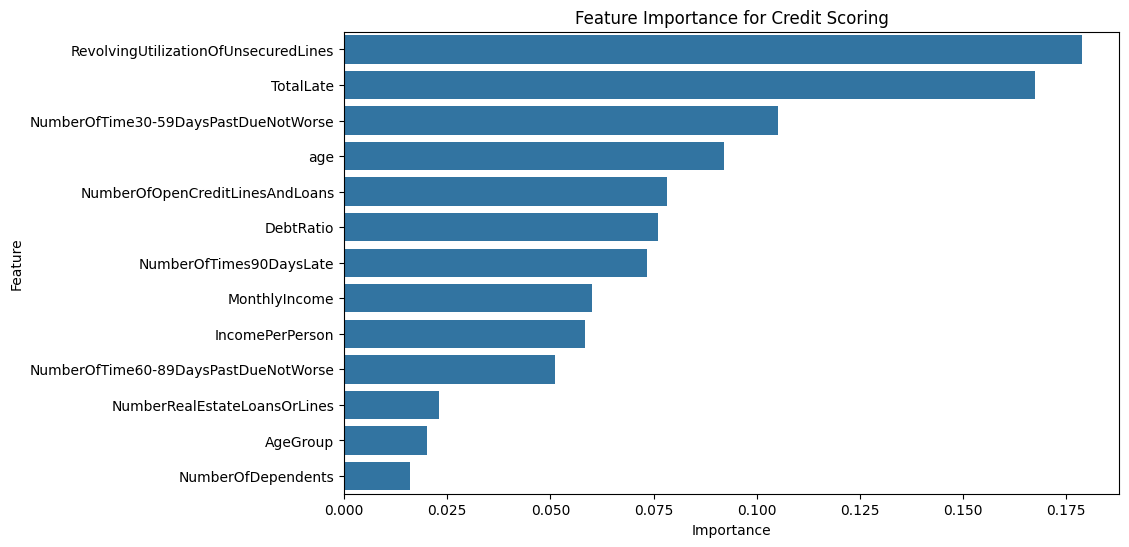

In [7]:
# 3. 변수 중요도 추출
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Credit Scoring')
plt.show()

"단순히 연체 횟수만 보는 것이 아니라, 한도 대비 사용액이 급격히 늘어나는 패턴을 포착하는 것이 잠재적 부도 위험을 예측하는 핵심 지표임을 확인했습니다."